<a href="https://colab.research.google.com/github/M-AdityoRahman/PCVK_Ganjil_2025/blob/main/week_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

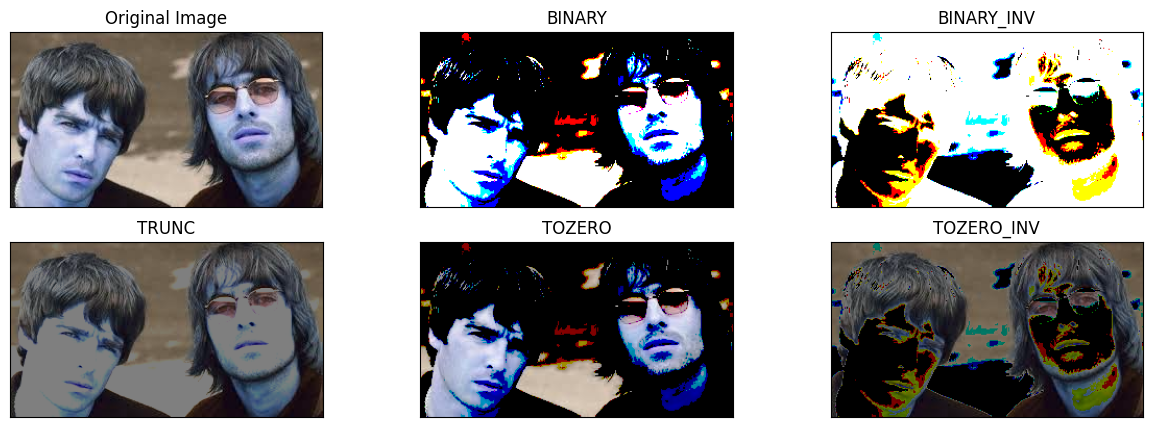

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
filename = ('/content/drive/MyDrive/PCVK/oasis.jpeg')
img = cv.imread(filename)
thresh = 127  # Nilai threshold
ret, thresh1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)
ret, thresh2 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY_INV)
ret, thresh3 = cv.threshold(img, thresh, 255, cv.THRESH_TRUNC)
ret, thresh4 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO)
ret, thresh5 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO_INV)

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()

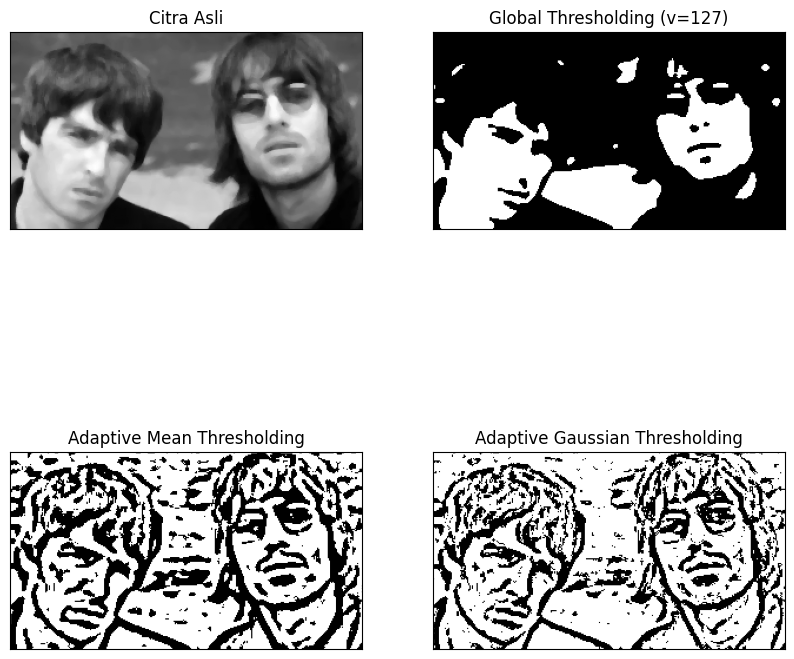

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/PCVK/oasis.jpeg'
img = cv.imread(filename)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray = cv.medianBlur(gray, 5)

# Global Thresholding
ret, th1 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Adaptive Mean
th2 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                           cv.THRESH_BINARY, 11, 2)

# Adaptive Gaussian
th3 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                           cv.THRESH_BINARY, 11, 2)

titles = ['Citra Asli', 'Global Thresholding (v=127)',
          'Adaptive Mean Thresholding', 'Adaptive Gaussian Thresholding']
images = [gray, th1, th2, th3]

plt.figure(figsize=(10, 10))
for i in range(len(images)):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


/tmp/ipython-input-1249633942.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [50, 200])


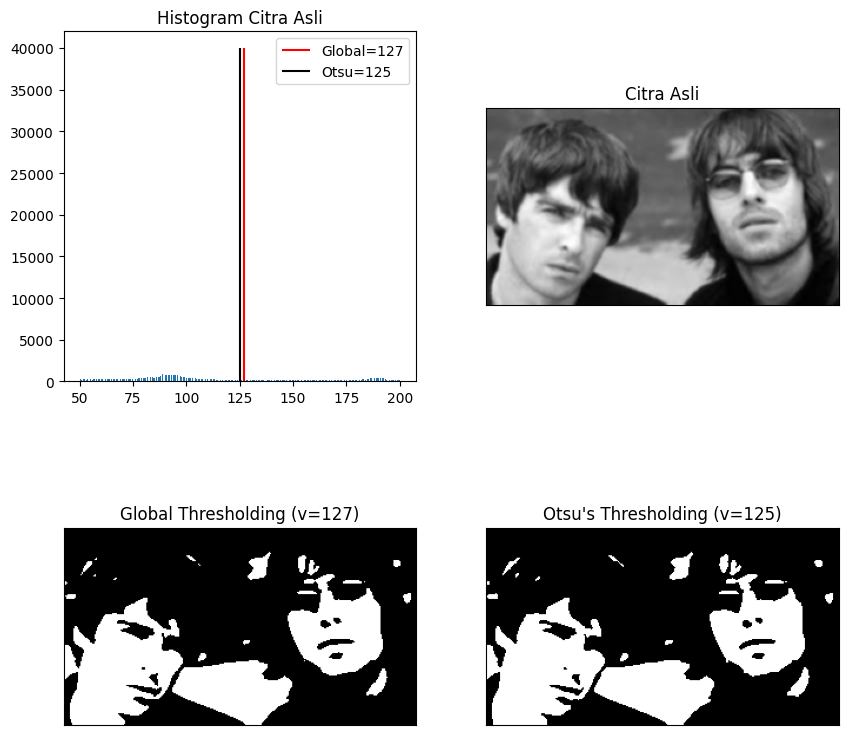

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/PCVK/oasis.jpeg'
img = cv.imread(filename, 0)

# Gaussian blur untuk mengurangi noise
blur = cv.GaussianBlur(img, (5, 5), 0)

# Global Threshold
ret1, th1 = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)

# Otsu’s Thresholding
ret2, th2 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.hist(blur.ravel(), 256, [50, 200])
plt.vlines(ret1, 0, 40000, colors='red', label='Global=127')
plt.vlines(ret2, 0, 40000, colors='black', label=f'Otsu={ret2:.0f}')
plt.legend()
plt.title('Histogram Citra Asli')

titles = ['Citra Asli', 'Global Thresholding (v=127)', f"Otsu's Thresholding (v={ret2:.0f})"]
images = [blur, th1, th2]
for i in range(len(images)):
    plt.subplot(2, 2, i+2)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

file_path = "/content/drive/MyDrive/PCVK/oasis.jpeg"
img = cv2.imread(file_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pixels = img_rgb.reshape(-1, 3)
k = 5  # Jumlah klaster warna
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(pixels)
cluster_centers = kmeans.cluster_centers_.astype(int)
labels = kmeans.labels_

# Deteksi klaster warna kuning
def is_yellow(color):
    r, g, b = color
    return r > 150 and g > 150 and b < 100

yellow_cluster = None
for idx, center in enumerate(cluster_centers):
    if is_yellow(center):
        yellow_cluster = idx
        print(f"Klaster ke-{idx} terdeteksi sebagai kuning: {center}")
        break

if yellow_cluster is not None:
    mask = (labels == yellow_cluster)
    yellow_pixels = np.zeros_like(pixels)
    yellow_pixels[mask] = pixels[mask]
    yellow_img = yellow_pixels.reshape(img_rgb.shape)

    white_bg = yellow_img.copy()
    white_bg[np.all(white_bg == [0, 0, 0], axis=-1)] = [255, 255, 255]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Gambar Asli")
    axes[0].axis('off')
    axes[1].imshow(white_bg)
    axes[1].set_title("Segmen Warna Kuning")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


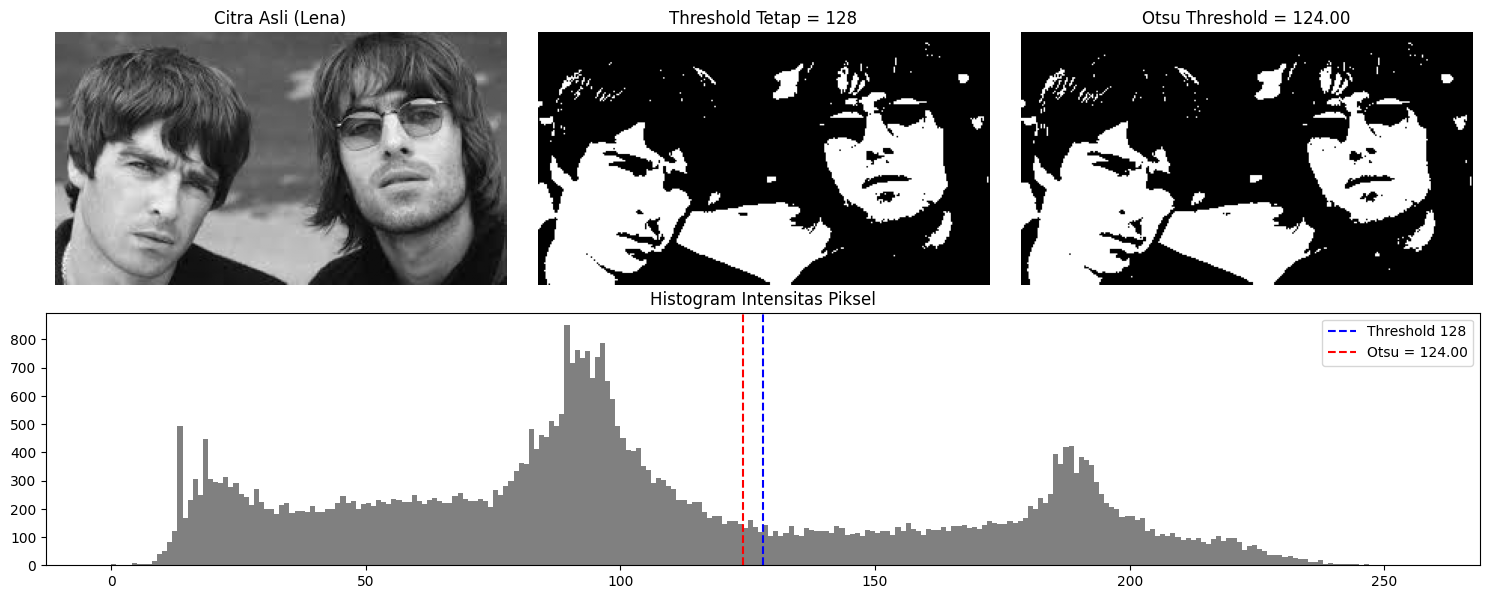

In [7]:
import cv2
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/PCVK/oasis.jpeg'
image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if image is not None:
    threshold_value = 128
    _, segmented_fixed = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)
    otsu_value, segmented_otsu = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    plt.figure(figsize=(15, 6))
    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Citra Asli (Lena)')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(segmented_fixed, cmap='gray')
    plt.title(f'Threshold Tetap = {threshold_value}')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(segmented_otsu, cmap='gray')
    plt.title(f'Otsu Threshold = {otsu_value:.2f}')
    plt.axis('off')

    plt.subplot(2, 1, 2)
    plt.hist(image.ravel(), bins=256, range=(0, 256), color='gray')
    plt.axvline(x=threshold_value, color='blue', linestyle='--', label=f'Threshold 128')
    plt.axvline(x=otsu_value, color='red', linestyle='--', label=f'Otsu = {otsu_value:.2f}')
    plt.legend()
    plt.title('Histogram Intensitas Piksel')
    plt.tight_layout()
    plt.show()
